## Preprocessing

In [1]:
import pandas as pd
import numpy as np

In [2]:
cols = ['Unnamed: 0',
 'Flow ID',
 'Src IP',
 'Src Port',
 'Dst IP',
 'Dst Port',
 'Protocol',
 'Timestamp',
 'Flow Duration',
 'Tot Fwd Pkts',
 'Tot Bwd Pkts',
 'TotLen Fwd Pkts',
 'TotLen Bwd Pkts',
 'Fwd Pkt Len Max',
 'Fwd Pkt Len Min',
 'Fwd Pkt Len Mean',
 'Fwd Pkt Len Std',
 'Bwd Pkt Len Max',
 'Bwd Pkt Len Min',
 'Bwd Pkt Len Mean',
 'Bwd Pkt Len Std',
 'Flow Byts/s',
 'Flow Pkts/s',
 'Flow IAT Mean',
 'Flow IAT Std',
 'Flow IAT Max',
 'Flow IAT Min',
 'Fwd IAT Tot',
 'Fwd IAT Mean',
 'Fwd IAT Std',
 'Fwd IAT Max',
 'Fwd IAT Min',
 'Bwd IAT Tot',
 'Bwd IAT Mean',
 'Bwd IAT Std',
 'Bwd IAT Max',
 'Bwd IAT Min',
 'Fwd PSH Flags',
 'Bwd PSH Flags',
 'Fwd URG Flags',
 'Bwd URG Flags',
 'Fwd Header Len',
 'Bwd Header Len',
 'Fwd Pkts/s',
 'Bwd Pkts/s',
 'Pkt Len Min',
 'Pkt Len Max',
 'Pkt Len Mean',
 'Pkt Len Std',
 'Pkt Len Var',
 'FIN Flag Cnt',
 'SYN Flag Cnt',
 'RST Flag Cnt',
 'PSH Flag Cnt',
 'ACK Flag Cnt',
 'URG Flag Cnt',
 'CWE Flag Count',
 'ECE Flag Cnt',
 'Down/Up Ratio',
 'Pkt Size Avg',
 'Fwd Seg Size Avg',
 'Bwd Seg Size Avg',
 'Fwd Byts/b Avg',
 'Fwd Pkts/b Avg',
 'Fwd Blk Rate Avg',
 'Bwd Byts/b Avg',
 'Bwd Pkts/b Avg',
 'Bwd Blk Rate Avg',
 'Subflow Fwd Pkts',
 'Subflow Fwd Byts',
 'Subflow Bwd Pkts',
 'Subflow Bwd Byts',
 'Init Fwd Win Byts',
 'Init Bwd Win Byts',
 'Fwd Act Data Pkts',
 'Fwd Seg Size Min',
 'Active Mean',
 'Active Std',
 'Active Max',
 'Active Min',
 'Idle Mean',
 'Idle Std',
 'Idle Max',
 'Idle Min',
 'Label']

In [3]:
chunks = []
chunk_size = 100000

for chunk_idx, chunk in enumerate(pd.read_csv("/kaggle/input/ddos-datasets/ddos_balanced/final_dataset.csv", chunksize=chunk_size)):
    chunk_ = chunk.sample(frac=0.05, random_state=42)
    chunks.append(chunk_)
    if chunk_idx%10 == 0:
        print(f"Chunk {chunk_idx} done")
print("Complete")

Chunk 0 done
Chunk 10 done
Chunk 20 done
Chunk 30 done
Chunk 40 done
Chunk 50 done
Chunk 60 done
Chunk 70 done
Chunk 80 done
Chunk 90 done
Chunk 100 done
Chunk 110 done
Chunk 120 done
Complete


In [4]:
df = pd.concat(chunks, ignore_index=True)
del chunks

In [5]:
df["Label"].value_counts()

Label
ddos      323654
Benign    316077
Name: count, dtype: int64

In [6]:
df.to_parquet('/kaggle/working/sample_data.parquet', index=False)
print("Wrote file")

Wrote file


Uncomment to load the file

In [7]:
# df = pd.read_parquet("/kaggle/working/sample_data.parquet")

In [8]:
df.head()

,Unnamed: 0,Flow ID,Src IP,Src Port,Dst IP,Dst Port,Protocol,Timestamp,Flow Duration,Tot Fwd Pkts,...,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,22165,172.31.69.25-18.219.211.138-80-34408-6,18.219.211.138,34408,172.31.69.25,80,6,15/02/2018 07:24:59 PM,5032233,3,...,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,ddos
1,26628,172.31.69.25-18.219.211.138-80-40676-6,18.219.211.138,40676,172.31.69.25,80,6,15/02/2018 07:26:24 PM,10993127,3,...,0,783.0,0.0,783.0,783.0,5990709.0,0.0,5990709.0,5990709.0,ddos
2,76682,192.168.2.109-203.73.24.75-4020-80-6,192.168.2.109,4020,203.73.24.75,80,6,12/06/2010 03:12:15 PM,479425,3,...,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,ddos
3,23143,172.31.69.25-18.219.211.138-80-36102-6,18.219.211.138,36102,172.31.69.25,80,6,15/02/2018 07:08:53 PM,9042123,1,...,0,0.0,0.0,0.0,0.0,9042123.0,0.0,9042123.0,9042123.0,ddos
4,39435,172.31.69.25-18.219.211.138-80-44284-6,18.219.211.138,44284,172.31.69.25,80,6,15/02/2018 07:19:56 PM,1907579,1,...,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,ddos


In [9]:
df.columns.tolist()

['Unnamed: 0',
 'Flow ID',
 'Src IP',
 'Src Port',
 'Dst IP',
 'Dst Port',
 'Protocol',
 'Timestamp',
 'Flow Duration',
 'Tot Fwd Pkts',
 'Tot Bwd Pkts',
 'TotLen Fwd Pkts',
 'TotLen Bwd Pkts',
 'Fwd Pkt Len Max',
 'Fwd Pkt Len Min',
 'Fwd Pkt Len Mean',
 'Fwd Pkt Len Std',
 'Bwd Pkt Len Max',
 'Bwd Pkt Len Min',
 'Bwd Pkt Len Mean',
 'Bwd Pkt Len Std',
 'Flow Byts/s',
 'Flow Pkts/s',
 'Flow IAT Mean',
 'Flow IAT Std',
 'Flow IAT Max',
 'Flow IAT Min',
 'Fwd IAT Tot',
 'Fwd IAT Mean',
 'Fwd IAT Std',
 'Fwd IAT Max',
 'Fwd IAT Min',
 'Bwd IAT Tot',
 'Bwd IAT Mean',
 'Bwd IAT Std',
 'Bwd IAT Max',
 'Bwd IAT Min',
 'Fwd PSH Flags',
 'Bwd PSH Flags',
 'Fwd URG Flags',
 'Bwd URG Flags',
 'Fwd Header Len',
 'Bwd Header Len',
 'Fwd Pkts/s',
 'Bwd Pkts/s',
 'Pkt Len Min',
 'Pkt Len Max',
 'Pkt Len Mean',
 'Pkt Len Std',
 'Pkt Len Var',
 'FIN Flag Cnt',
 'SYN Flag Cnt',
 'RST Flag Cnt',
 'PSH Flag Cnt',
 'ACK Flag Cnt',
 'URG Flag Cnt',
 'CWE Flag Count',
 'ECE Flag Cnt',
 'Down/Up Ratio',
 'Pk

In [10]:
df.drop(columns=["Unnamed: 0", "Flow ID"], inplace=True)

In [11]:
df.head()

,Src IP,Src Port,Dst IP,Dst Port,Protocol,Timestamp,Flow Duration,Tot Fwd Pkts,Tot Bwd Pkts,TotLen Fwd Pkts,...,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,18.219.211.138,34408,172.31.69.25,80,6,15/02/2018 07:24:59 PM,5032233,3,5,603.0,...,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,ddos
1,18.219.211.138,40676,172.31.69.25,80,6,15/02/2018 07:26:24 PM,10993127,3,5,408.0,...,0,783.0,0.0,783.0,783.0,5990709.0,0.0,5990709.0,5990709.0,ddos
2,192.168.2.109,4020,203.73.24.75,80,6,12/06/2010 03:12:15 PM,479425,3,7,142.0,...,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,ddos
3,18.219.211.138,36102,172.31.69.25,80,6,15/02/2018 07:08:53 PM,9042123,1,1,0.0,...,0,0.0,0.0,0.0,0.0,9042123.0,0.0,9042123.0,9042123.0,ddos
4,18.219.211.138,44284,172.31.69.25,80,6,15/02/2018 07:19:56 PM,1907579,1,1,0.0,...,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,ddos


In [12]:
# Convert IP strings into octets efficiently using NumPy
def ip_to_octets(ip_series, prefix):
    octets = np.stack(ip_series.str.split('.').apply(lambda x: list(map(int, x))))
    return pd.DataFrame(octets, columns=[f"{prefix} Octet{i+1}" for i in range(4)])

In [13]:
# Apply the optimized function
src_octets = ip_to_octets(df["Src IP"], "Src IP")
dst_octets = ip_to_octets(df["Dst IP"], "Dst IP")

# Concatenate with original DataFrame
df = pd.concat([df, src_octets, dst_octets], axis=1).drop(columns=["Src IP", "Dst IP"])

# Done
print("IP segmentation Done")

# Delete unused vars
del src_octets
del dst_octets

IP segmentation Done


In [14]:
columns_with_nan = df.columns[df.isnull().any()]

for col in columns_with_nan:
    print(f"Column '{col}' has {df[col].isnull().sum()} NaN values")

Column 'Flow Byts/s' has 1454 NaN values


In [15]:
df.replace([np.inf, -np.inf], np.nan, inplace=True)

In [16]:
df = pd.DataFrame(df.dropna(), columns=df.columns)

In [17]:
y = df["Label"]
X = df.drop(columns=["Label"])

In [18]:
print(y.isnull().any().sum())
print(X.isnull().any().sum())

0
0


In [19]:
y.nunique()

2

In [20]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.model_selection import train_test_split

In [21]:
numerical_cols = X.select_dtypes(include=np.number).columns.tolist()
non_numerical_cols = X.select_dtypes(exclude=np.number).columns.tolist()
train_X, test_X, train_y, test_y = train_test_split(X, y, test_size=0.2)

print(train_X.isnull().any(axis=1).sum())
print(test_X.isnull().any(axis=1).sum())
print(train_y.isnull().sum())
print(test_y.isnull().sum())

0
0
0
0


In [22]:
non_numerical_cols

['Timestamp']

In [23]:
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy="mean")

train_X[numerical_cols] = pd.DataFrame(imputer.fit_transform(train_X[numerical_cols]), columns=numerical_cols, index=train_X.index)  # DO NOT remove the index=xxx attribute, else NaN happens
test_X[numerical_cols] = pd.DataFrame(imputer.transform(test_X[numerical_cols]), columns=numerical_cols, index=test_X.index)

print(train_X.isnull().any(axis=1).sum())
print(test_X.isnull().any(axis=1).sum())

print("Imputing complete")

0
0
Imputing complete


In [24]:
scaler = MinMaxScaler()
train_scaled = scaler.fit_transform(train_X[numerical_cols])
train_X[numerical_cols] = pd.DataFrame(train_scaled, columns=numerical_cols, index=train_X.index)
test_X[numerical_cols] = pd.DataFrame(scaler.transform(test_X[numerical_cols]), columns=numerical_cols, index=test_X.index)

print(train_X.isnull().any(axis=1).sum())
print(test_X.isnull().any(axis=1).sum())

print("Scaling complete")

0
0
Scaling complete


In [25]:
train_X.head()
train_X.shape

(509913, 88)

In [26]:
train_X.head()

,Src Port,Dst Port,Protocol,Timestamp,Flow Duration,Tot Fwd Pkts,Tot Bwd Pkts,TotLen Fwd Pkts,TotLen Bwd Pkts,Fwd Pkt Len Max,...,Idle Max,Idle Min,Src IP Octet1,Src IP Octet2,Src IP Octet3,Src IP Octet4,Dst IP Octet1,Dst IP Octet2,Dst IP Octet3,Dst IP Octet4
102290,0.001221,0.917676,0.352941,22/02/2018 12:22:37 AM,0.027537,0.000013,0.000185,0.000094,0.000009,0.040026,...,0.0,0.0,0.770270,0.121569,0.270588,0.109804,0.066929,0.847059,0.094118,0.164706
177614,0.919417,0.001221,0.352941,16/02/2018 11:19:43 PM,0.036030,0.000013,0.000277,0.000031,0.000030,0.013271,...,0.0,0.0,0.076577,0.858824,0.756863,0.078431,0.673228,0.121569,0.270588,0.098039
252096,0.001221,0.616626,0.352941,16/02/2018 11:17:51 PM,0.036080,0.000013,0.000185,0.000094,0.000010,0.040026,...,0.0,0.0,0.770270,0.121569,0.270588,0.098039,0.066929,0.858824,0.756863,0.078431
165525,0.723095,0.001221,0.352941,16/02/2018 11:18:06 PM,0.000196,0.000003,0.000046,0.000000,0.000000,0.000000,...,0.0,0.0,0.076577,0.858824,0.756863,0.078431,0.673228,0.121569,0.270588,0.098039
482044,0.860273,0.000809,1.000000,03/07/2017 10:47:34 PM,0.000001,0.000003,0.000139,0.000004,0.000005,0.001670,...,0.0,0.0,0.860360,0.658824,0.039216,0.058824,0.751969,0.658824,0.039216,0.011765


In [27]:
train_X.isnull().any(axis=1).sum()

0

In [28]:
train_y = train_y.map({"Benign": 0, "ddos": 1})

In [29]:
test_y = test_y.map({"Benign": 0, "ddos": 1})

In [30]:
print(train_y.isnull().sum())
print(test_y.isnull().sum())

0
0


In [31]:
# to_parquet is only in a DF, so make DFs for Series objects
train_y_df = pd.DataFrame(train_y)
test_y_df = pd.DataFrame(test_y)

train_X.to_parquet("train_scaled_X.parquet")
test_X.to_parquet("test_scaled_X.parquet")
train_y_df.to_parquet("train_scaled_y.parquet")
test_y_df.to_parquet("test_scaled_y.parquet")

print("Files were written")

Files were written


## Logistic Regression

In [32]:
from sklearn.linear_model import LogisticRegression

# Train
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(train_X[numerical_cols], train_y.reset_index(drop=True))

# Print
print("Model trained successfully")

Model trained successfully


In [33]:
y_pred = model.predict(test_X[numerical_cols])

In [34]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

In [35]:
train_X[numerical_cols].shape, test_X[numerical_cols].shape

((509913, 87), (127479, 87))

In [36]:
print("Accuracy:", accuracy_score(test_y.reset_index(drop=True), y_pred))
print("\nClassification Report:\n", classification_report(test_y, y_pred))


Accuracy: 0.9919751488480456

Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.99      0.99     62723
           1       0.99      0.99      0.99     64756

    accuracy                           0.99    127479
   macro avg       0.99      0.99      0.99    127479
weighted avg       0.99      0.99      0.99    127479



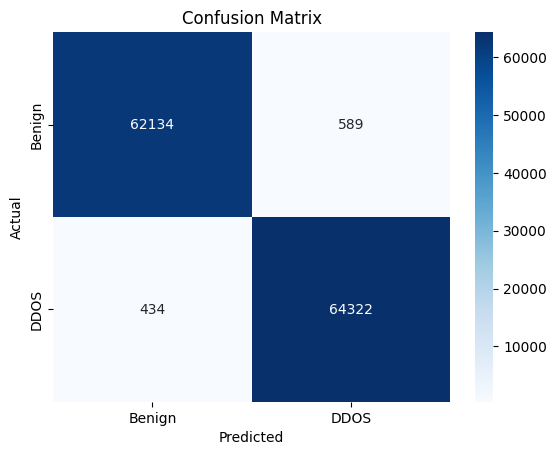

In [37]:
conf_matrix = confusion_matrix(test_y.reset_index(drop=True), y_pred)
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=['Benign', 'DDOS'], yticklabels=['Benign', 'DDOS'])
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

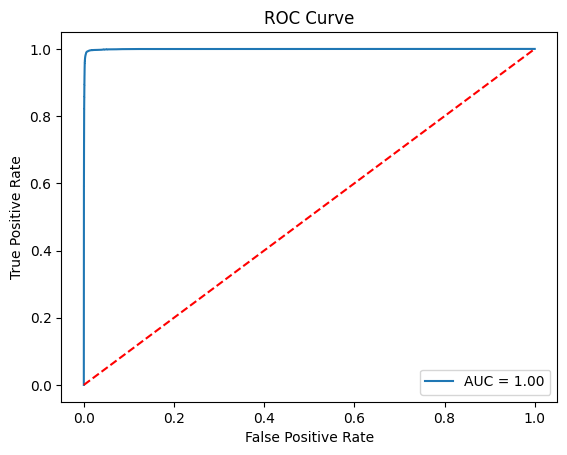

In [38]:
y_pred_proba = model.predict_proba(test_X[numerical_cols])[:,1]
fpr, tpr, _ = roc_curve(test_y.reset_index(drop=True), y_pred_proba)
auc = roc_auc_score(test_y.reset_index(drop=True), y_pred_proba)
plt.plot(fpr, tpr, label="AUC = {:.2f}".format(auc))
plt.plot([0, 1], [0, 1], 'r--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [39]:
import joblib
joblib.dump(model, '/kaggle/working/log_reg_model.pkl')

['/kaggle/working/log_reg_model.pkl']

## Autoencoder

In [40]:
train_X.head()

,Src Port,Dst Port,Protocol,Timestamp,Flow Duration,Tot Fwd Pkts,Tot Bwd Pkts,TotLen Fwd Pkts,TotLen Bwd Pkts,Fwd Pkt Len Max,...,Idle Max,Idle Min,Src IP Octet1,Src IP Octet2,Src IP Octet3,Src IP Octet4,Dst IP Octet1,Dst IP Octet2,Dst IP Octet3,Dst IP Octet4
102290,0.001221,0.917676,0.352941,22/02/2018 12:22:37 AM,0.027537,0.000013,0.000185,0.000094,0.000009,0.040026,...,0.0,0.0,0.770270,0.121569,0.270588,0.109804,0.066929,0.847059,0.094118,0.164706
177614,0.919417,0.001221,0.352941,16/02/2018 11:19:43 PM,0.036030,0.000013,0.000277,0.000031,0.000030,0.013271,...,0.0,0.0,0.076577,0.858824,0.756863,0.078431,0.673228,0.121569,0.270588,0.098039
252096,0.001221,0.616626,0.352941,16/02/2018 11:17:51 PM,0.036080,0.000013,0.000185,0.000094,0.000010,0.040026,...,0.0,0.0,0.770270,0.121569,0.270588,0.098039,0.066929,0.858824,0.756863,0.078431
165525,0.723095,0.001221,0.352941,16/02/2018 11:18:06 PM,0.000196,0.000003,0.000046,0.000000,0.000000,0.000000,...,0.0,0.0,0.076577,0.858824,0.756863,0.078431,0.673228,0.121569,0.270588,0.098039
482044,0.860273,0.000809,1.000000,03/07/2017 10:47:34 PM,0.000001,0.000003,0.000139,0.000004,0.000005,0.001670,...,0.0,0.0,0.860360,0.658824,0.039216,0.058824,0.751969,0.658824,0.039216,0.011765


In [41]:
train_y.reset_index(drop=True).head()
pd.DataFrame(train_y).head()

,Label
102290,1
177614,1
252096,1
165525,1
482044,0


In [42]:
# train_X_benign = train_X[pd.DataFrame(train_y).reset_index(drop=True)["Label"]==0].reset_index(drop=True)  # TODO: Why this doesn't work??
train_X_benign = train_X[pd.DataFrame(train_y)["Label"]==0].reset_index(drop=True)[numerical_cols]
train_X_benign.isna().any(axis=1).sum()

0

In [43]:
train_X_benign.head()

,Src Port,Dst Port,Protocol,Flow Duration,Tot Fwd Pkts,Tot Bwd Pkts,TotLen Fwd Pkts,TotLen Bwd Pkts,Fwd Pkt Len Max,Fwd Pkt Len Min,...,Idle Max,Idle Min,Src IP Octet1,Src IP Octet2,Src IP Octet3,Src IP Octet4,Dst IP Octet1,Dst IP Octet2,Dst IP Octet3,Dst IP Octet4
0,0.860273,0.000809,1.000000,1.275000e-06,0.000003,0.000139,0.000004,0.000005,0.001670,0.026495,...,0.0,0.0,0.860360,0.658824,0.039216,0.058824,0.751969,0.658824,0.039216,0.011765
1,0.001221,0.752098,0.352941,3.666667e-07,0.000003,0.000046,0.000000,0.000000,0.000000,0.000000,...,0.0,0.0,0.770270,0.850980,0.047059,0.886275,0.673228,0.121569,0.254902,0.458824
2,0.757946,0.006760,0.352941,6.440001e-04,0.000006,0.000046,0.000007,0.000004,0.003168,0.000000,...,0.0,0.0,0.770270,0.121569,0.270588,0.043137,0.047244,0.349020,0.749020,0.176471
3,0.837980,0.000809,1.000000,2.203500e-02,0.000006,0.000092,0.000008,0.000007,0.001798,0.023777,...,0.0,0.0,0.770270,0.121569,0.262745,0.035294,0.673228,0.121569,0.000000,0.007843
4,0.006760,0.988922,0.352941,1.666667e-08,0.000003,0.000046,0.000000,0.000001,0.000000,0.000000,...,0.0,0.0,0.238739,0.717647,0.180392,0.682353,0.751969,0.658824,0.039216,0.098039


In [44]:
import torch
import torch.nn as nn
import torch.optim as optim

In [45]:
class Autoencoder(nn.Module):
    def __init__(self, input_dim): # x -> x' -> x'' 
        super(Autoencoder, self).__init__()
        # Encoder
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.SELU(),
            nn.Linear(64, 32),
            nn.SELU(),
            nn.Linear(32, 8),
            nn.SELU()
        )
        # Decoder
        self.decoder = nn.Sequential(
            nn.Linear(8, 32),
            nn.SELU(),
            nn.Linear(32, 64),
            nn.SELU(),
            nn.Linear(64, input_dim),
            nn.SELU()
        )
        
    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded

In [46]:
input_dim = train_X_benign.shape[1]
model = Autoencoder(input_dim)
criterion = nn.L1Loss()
optimizer = optim.RMSprop(model.parameters(), lr=0.0001)

In [47]:
# train_X_backup = train_X.copy()
# test_X_backup = test_X.copy()
# train_y_backup = train_y.copy()
# test_y_backup = test_y.copy()
# train_X_benign_backup = train_X_benign.copy()

# train_X = train_X_backup.copy()
# test_X = test_X_backup.copy()
# train_y = train_y_backup.copy()
# test_y = test_y_backup.copy()
# train_X_benign = train_X_benign_backup.copy()

In [48]:
if not isinstance(train_X, torch.Tensor):
    train_X = torch.FloatTensor(train_X[numerical_cols].values)
if not isinstance(train_y, torch.Tensor):
    train_y = torch.LongTensor(train_y.values)
if not isinstance(test_X, torch.Tensor):
    test_X = torch.FloatTensor(test_X[numerical_cols].values)
if not isinstance(test_y, torch.Tensor):
    test_y = torch.LongTensor(test_y.values)
if not isinstance(train_X_benign, torch.Tensor):
    train_X_benign = torch.FloatTensor(train_X_benign.values)

In [49]:
print(type(train_X))
print(type(train_y))
print(type(test_X))
print(type(test_y))
print(type(train_X_benign))

<class 'torch.Tensor'>
<class 'torch.Tensor'>
<class 'torch.Tensor'>
<class 'torch.Tensor'>
<class 'torch.Tensor'>


In [50]:
from torch.utils.data import DataLoader, TensorDataset

train_loader = DataLoader(TensorDataset(train_X_benign), batch_size=32, shuffle=True)
epochs = 30

In [51]:
epoch_losses = []
reconstruction_losses_last_epoch = [] 
for epoch in range(epochs):
    model.train()   # set the model to training mode 
    total_loss = 0
    # using mini batch gradient descent
    for batch in train_loader:
        inputs = batch[0]
        optimizer.zero_grad()    # reset the gradients for each batch
        outputs = model(inputs)  # forward pass
        loss = criterion(outputs, inputs)    
        loss.backward()     # backward pass
        optimizer.step()    # update the weights
        total_loss += loss.item()

        # Track individual sample reconstruction losses only in the last epoch
        if epoch == epochs - 1:  # Collect only for the last epoch
            reconstruction_losses_last_epoch.extend(loss.item() for _ in range(len(inputs)))
            
    epoch_loss = total_loss/len(train_loader)
    epoch_losses.append(epoch_loss)
    print(f'Epoch {epoch+1}/{epochs}, Loss: {total_loss/len(train_loader):.4f}') 
print("Autoencoder training complete")

Epoch 1/30, Loss: 0.0428
Epoch 2/30, Loss: 0.0356
Epoch 3/30, Loss: 0.0315
Epoch 4/30, Loss: 0.0294
Epoch 5/30, Loss: 0.0246
Epoch 6/30, Loss: 0.0226
Epoch 7/30, Loss: 0.0222
Epoch 8/30, Loss: 0.0218
Epoch 9/30, Loss: 0.0214
Epoch 10/30, Loss: 0.0212
Epoch 11/30, Loss: 0.0210
Epoch 12/30, Loss: 0.0208
Epoch 13/30, Loss: 0.0207
Epoch 14/30, Loss: 0.0206
Epoch 15/30, Loss: 0.0204
Epoch 16/30, Loss: 0.0203
Epoch 17/30, Loss: 0.0202
Epoch 18/30, Loss: 0.0201
Epoch 19/30, Loss: 0.0200
Epoch 20/30, Loss: 0.0195
Epoch 21/30, Loss: 0.0183
Epoch 22/30, Loss: 0.0180
Epoch 23/30, Loss: 0.0178
Epoch 24/30, Loss: 0.0177
Epoch 25/30, Loss: 0.0176
Epoch 26/30, Loss: 0.0175
Epoch 27/30, Loss: 0.0174
Epoch 28/30, Loss: 0.0173
Epoch 29/30, Loss: 0.0172
Epoch 30/30, Loss: 0.0172
Autoencoder training complete


In [52]:
from sklearn.metrics import precision_recall_fscore_support, roc_auc_score

reconstruction_losses_last_epoch = np.array(reconstruction_losses_last_epoch)

mean_loss = np.mean(reconstruction_losses_last_epoch)
std_loss = np.std(reconstruction_losses_last_epoch)

threshold = 1 * mean_loss + 2.5 * std_loss # Define threshold to have the highest recall possible. 

print(f"Anomaly Detection Threshold: {threshold}")

Anomaly Detection Threshold: 0.023247932980669968


In [53]:
model.eval()
reconstruction_errors = []
test_labels = test_y.numpy()

with torch.no_grad():
    outputs = model(test_X)
    reconstruction_errors = torch.mean(torch.abs(outputs - test_X), dim=1).numpy()

predicted_labels = (reconstruction_errors > threshold).astype(int)

In [54]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [55]:
accuracy = accuracy_score(test_labels, predicted_labels)
precision = precision_score(test_labels, predicted_labels)
recall = recall_score(test_labels, predicted_labels)
f1 = f1_score(test_labels, predicted_labels)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")

Accuracy: 0.8547
Precision: 0.7776
Recall: 1.0000
F1 Score: 0.8749


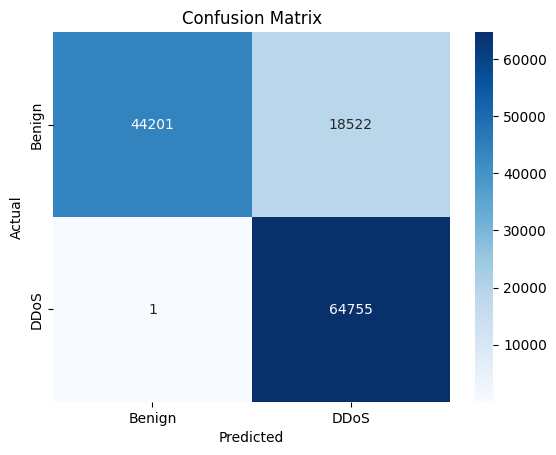

In [56]:
cm = confusion_matrix(test_labels, predicted_labels)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Benign', 'DDoS'], yticklabels=['Benign', 'DDoS'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [57]:
torch.save(model, "/kaggle/working/autoencoder.pt")

## LSTM

In [58]:
# Scaled data loading
train_scaled_X = pd.read_parquet("train_scaled_X.parquet")
test_scaled_X = pd.read_parquet("test_scaled_X.parquet")
train_scaled_y_df = pd.read_parquet("train_scaled_y.parquet")
test_scaled_y_df = pd.read_parquet("test_scaled_y.parquet")

# DF to Series conversion (as this is the default type of y)
train_scaled_y = train_scaled_y_df['Label']
test_scaled_y = test_scaled_y_df['Label']

print("Files loaded successfully")

Files loaded successfully


For now let's consider the training set as our only data source and train the LSTM on it

### merge y to X

In [59]:
data = train_scaled_X.copy()
data['Label'] = train_scaled_y.copy()
data.head(30)

,Src Port,Dst Port,Protocol,Timestamp,Flow Duration,Tot Fwd Pkts,Tot Bwd Pkts,TotLen Fwd Pkts,TotLen Bwd Pkts,Fwd Pkt Len Max,...,Idle Min,Src IP Octet1,Src IP Octet2,Src IP Octet3,Src IP Octet4,Dst IP Octet1,Dst IP Octet2,Dst IP Octet3,Dst IP Octet4,Label
102290,0.001221,0.917676,0.352941,22/02/2018 12:22:37 AM,2.753666e-02,0.000013,0.000185,0.000094,0.000009,0.040026,...,0.000000,0.770270,0.121569,0.270588,0.109804,0.066929,0.847059,0.094118,0.164706,1
177614,0.919417,0.001221,0.352941,16/02/2018 11:19:43 PM,3.602962e-02,0.000013,0.000277,0.000031,0.000030,0.013271,...,0.000000,0.076577,0.858824,0.756863,0.078431,0.673228,0.121569,0.270588,0.098039,1
252096,0.001221,0.616626,0.352941,16/02/2018 11:17:51 PM,3.608049e-02,0.000013,0.000185,0.000094,0.000010,0.040026,...,0.000000,0.770270,0.121569,0.270588,0.098039,0.066929,0.858824,0.756863,0.078431,1
165525,0.723095,0.001221,0.352941,16/02/2018 11:18:06 PM,1.956500e-04,0.000003,0.000046,0.000000,0.000000,0.000000,...,0.000000,0.076577,0.858824,0.756863,0.078431,0.673228,0.121569,0.270588,0.098039,1
482044,0.860273,0.000809,1.000000,03/07/2017 10:47:34 PM,1.275000e-06,0.000003,0.000139,0.000004,0.000005,0.001670,...,0.000000,0.860360,0.658824,0.039216,0.058824,0.751969,0.658824,0.039216,0.011765,0
147415,0.861128,0.000320,0.352941,16/02/2018 08:29:33 PM,1.666667e-08,0.000000,0.000092,0.000000,0.000000,0.000000,...,0.000000,0.054054,0.231373,0.494118,0.121569,0.673228,0.121569,0.270588,0.098039,1
427091,0.001221,0.752098,0.352941,20/02/2018 08:39:54,3.666667e-07,0.000003,0.000046,0.000000,0.000000,0.000000,...,0.000000,0.770270,0.850980,0.047059,0.886275,0.673228,0.121569,0.254902,0.458824,0
636115,0.757946,0.006760,0.352941,20/02/2018 01:45:40,6.440001e-04,0.000006,0.000046,0.000007,0.000004,0.003168,...,0.000000,0.770270,0.121569,0.270588,0.043137,0.047244,0.349020,0.749020,0.176471,0
52246,0.778256,0.001221,0.352941,22/02/2018 12:18:17 AM,1.419167e-05,0.000003,0.000046,0.000000,0.000000,0.000000,...,0.000000,0.076577,0.854902,0.450980,0.235294,0.673228,0.121569,0.270588,0.109804,1
3165,0.017090,0.001221,0.352941,12/06/2010 02:36:01 PM,1.014654e-02,0.000006,0.000231,0.000009,0.000020,0.003896,...,0.000000,0.860360,0.658824,0.007843,0.427451,0.795276,0.286275,0.094118,0.294118,1


In [60]:
# def parse_timestamp(timestamp_str):
#     """Parses timestamp strings, handling AM/PM and missing AM/PM."""
#     try:
#         # Attempt to parse with AM/PM
#         return pd.to_datetime(timestamp_str, format="%d/%m/%Y %I:%M:%S %p", errors='coerce')
#     except ValueError:
#         try:
#             # Attempt to parse without AM/PM (assumed AM)
#             return pd.to_datetime(timestamp_str, dayfirst=True, errors='coerce')
#         except ValueError:
#             return pd.NaT  # Return NaT for truly unparsable values

def parse_mixed_formats(timestamp):
    try:
        # Try parsing with AM/PM (12-hour format)
        return pd.to_datetime(timestamp, format="%d/%m/%Y %I:%M:%S %p", dayfirst=True)
    except ValueError:
        try:
            # Try parsing without AM/PM (24-hour format)
            return pd.to_datetime(timestamp, format="%d/%m/%Y %H:%M:%S", dayfirst=True)
        except ValueError:
            return pd.NaT  # Return NaT for invalid formats
            
# data['Timestampf'] = data['Timestamp'].apply(parse_timestamp)
# data['Timestampp'] = pd.to_datetime(data['Timestamp'], dayfirst=True, errors='coerce')
data['Timestamp'] = data['Timestamp'].apply(parse_mixed_formats)

print("Done TS parsing")

Done TS parsing


In [61]:
data.head(10)

,Src Port,Dst Port,Protocol,Timestamp,Flow Duration,Tot Fwd Pkts,Tot Bwd Pkts,TotLen Fwd Pkts,TotLen Bwd Pkts,Fwd Pkt Len Max,...,Idle Min,Src IP Octet1,Src IP Octet2,Src IP Octet3,Src IP Octet4,Dst IP Octet1,Dst IP Octet2,Dst IP Octet3,Dst IP Octet4,Label
102290,0.001221,0.917676,0.352941,2018-02-22 00:22:37,2.753666e-02,0.000013,0.000185,0.000094,0.000009,0.040026,...,0.0,0.770270,0.121569,0.270588,0.109804,0.066929,0.847059,0.094118,0.164706,1
177614,0.919417,0.001221,0.352941,2018-02-16 23:19:43,3.602962e-02,0.000013,0.000277,0.000031,0.000030,0.013271,...,0.0,0.076577,0.858824,0.756863,0.078431,0.673228,0.121569,0.270588,0.098039,1
252096,0.001221,0.616626,0.352941,2018-02-16 23:17:51,3.608049e-02,0.000013,0.000185,0.000094,0.000010,0.040026,...,0.0,0.770270,0.121569,0.270588,0.098039,0.066929,0.858824,0.756863,0.078431,1
165525,0.723095,0.001221,0.352941,2018-02-16 23:18:06,1.956500e-04,0.000003,0.000046,0.000000,0.000000,0.000000,...,0.0,0.076577,0.858824,0.756863,0.078431,0.673228,0.121569,0.270588,0.098039,1
482044,0.860273,0.000809,1.000000,2017-07-03 22:47:34,1.275000e-06,0.000003,0.000139,0.000004,0.000005,0.001670,...,0.0,0.860360,0.658824,0.039216,0.058824,0.751969,0.658824,0.039216,0.011765,0
147415,0.861128,0.000320,0.352941,2018-02-16 20:29:33,1.666667e-08,0.000000,0.000092,0.000000,0.000000,0.000000,...,0.0,0.054054,0.231373,0.494118,0.121569,0.673228,0.121569,0.270588,0.098039,1
427091,0.001221,0.752098,0.352941,2018-02-20 08:39:54,3.666667e-07,0.000003,0.000046,0.000000,0.000000,0.000000,...,0.0,0.770270,0.850980,0.047059,0.886275,0.673228,0.121569,0.254902,0.458824,0
636115,0.757946,0.006760,0.352941,2018-02-20 01:45:40,6.440001e-04,0.000006,0.000046,0.000007,0.000004,0.003168,...,0.0,0.770270,0.121569,0.270588,0.043137,0.047244,0.349020,0.749020,0.176471,0
52246,0.778256,0.001221,0.352941,2018-02-22 00:18:17,1.419167e-05,0.000003,0.000046,0.000000,0.000000,0.000000,...,0.0,0.076577,0.854902,0.450980,0.235294,0.673228,0.121569,0.270588,0.109804,1
3165,0.017090,0.001221,0.352941,2010-06-12 14:36:01,1.014654e-02,0.000006,0.000231,0.000009,0.000020,0.003896,...,0.0,0.860360,0.658824,0.007843,0.427451,0.795276,0.286275,0.094118,0.294118,1


In [62]:
# Check for pd.NaT in Timestamp column
print(data['Timestamp'].isnull().sum())

0


In [63]:
# save 
data.to_parquet("lstm_data.parquet")

print("Saving complete")

Saving complete


In [64]:
# load
# data = pd.read_parquet("/kaggle/working/lstm_data.parquet")
# data.equals(datax)

In [65]:
# for now forget about grouping and just train an LSTM just to see wtf is happening
data = data.sort_values(by='Timestamp')
data.head()

,Src Port,Dst Port,Protocol,Timestamp,Flow Duration,Tot Fwd Pkts,Tot Bwd Pkts,TotLen Fwd Pkts,TotLen Bwd Pkts,Fwd Pkt Len Max,...,Idle Min,Src IP Octet1,Src IP Octet2,Src IP Octet3,Src IP Octet4,Dst IP Octet1,Dst IP Octet2,Dst IP Octet3,Dst IP Octet4,Label
3818,0.069261,0.001221,0.352941,2010-06-12 08:37:06,3.920034e-03,0.000006,0.000231,0.000009,0.000031,0.003896,...,0.0,0.86036,0.658824,0.015686,0.462745,0.795276,0.286275,0.094118,0.294118,1
3805,0.069322,0.001221,0.352941,2010-06-12 08:37:09,1.993992e-03,0.000000,0.000092,0.000000,0.000000,0.000000,...,0.0,0.86036,0.658824,0.015686,0.462745,0.795276,0.286275,0.094118,0.294118,1
409,0.069398,0.001221,0.352941,2010-06-12 08:37:16,1.044278e-02,0.000029,0.000878,0.000012,0.000672,0.004966,...,0.0,0.86036,0.658824,0.015686,0.462745,0.795276,0.286275,0.094118,0.294118,1
2749,0.069459,0.001221,0.352941,2010-06-12 08:37:20,4.166668e-08,0.000003,0.000046,0.000000,0.000000,0.000000,...,0.0,0.86036,0.658824,0.015686,0.462745,0.795276,0.286275,0.094118,0.294118,1
4502,0.069490,0.001221,0.352941,2010-06-12 08:37:21,8.734294e-03,0.000019,0.000601,0.000012,0.000436,0.005051,...,0.0,0.86036,0.658824,0.015686,0.462745,0.795276,0.286275,0.094118,0.294118,1


In [66]:
# train_size = int(len(data) * 0.7)  # 80% for training
# train_data = data.iloc[:train_size]  # First 80% for training
# test_data = data.iloc[train_size:]  # Remaining 20% for testing

In [67]:
# train_data['Label'].value_counts()

In [68]:
# test_data['Label'].value_counts()

* Imbalance present but ignoring for now

In [69]:
# import numpy as np

# def create_sequences(data, seq_length=50):  # 50 time steps per sequence
#     sequences, labels = [], []
#     for i in range(len(data) - seq_length):
#         sequences.append(data[i:i+seq_length].values)  # Features for LSTM
#         labels.append(data.iloc[i+seq_length]['Label'])  # Target label
#     return np.array(sequences), np.array(labels)

# seq_length = 50  # Adjust based on your dataset

# X_train, y_train = create_sequences(train_data, seq_length)
# X_test, y_test = create_sequences(test_data, seq_length)

# print("Sequencing complte")


In [70]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

In [71]:
class NetworkTrafficDataset(Dataset):
    def __init__(self, data, seq_length=50):
        self.data = data
        self.seq_length = seq_length

    def __len__(self):
        return len(self.data) - self.seq_length  # Number of sequences

    def __getitem__(self, index):
        X = self.data.iloc[index:index + self.seq_length].drop(columns=['Label']).values
        y = self.data.iloc[index + self.seq_length]['Label']
        
        # Convert to tensors
        X_tensor = torch.tensor(X, dtype=torch.float32)
        y_tensor = torch.tensor(y, dtype=torch.long)  # Classification task
        
        return X_tensor, y_tensor


In [72]:
from sklearn.model_selection import train_test_split

# Load your dataset
# df = pd.read_csv("your_large_dataset.csv")  # Replace with actual file path
df = data.copy()

# Ensure data is sorted by timestamp
# df = df.sort_values(by="Timestamp")
# df = df.drop(columns=['Timestamp'])

# # Normalize features (except 'Label')
features = df.drop(columns=['Label', 'Timestamp'])
# features = (features - features.mean()) / features.std()  # Standardization
# df.loc[:, features.columns] = features

# Split into train and test sets
train_data, test_data = train_test_split(df, test_size=0.99, stratify=df['Label'], random_state=42)

# Ensure data is sorted by timestamp
train_data = train_data.sort_values(by="Timestamp")
train_data = train_data.drop(columns=["Timestamp"])
test_data = test_data.sort_values(by="Timestamp")
test_data = test_data.drop(columns=["Timestamp"])

# Sequence length
seq_length = 50
batch_size = 32

# Create Dataset and DataLoader
train_dataset = NetworkTrafficDataset(train_data, seq_length)
test_dataset = NetworkTrafficDataset(test_data, seq_length)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)


In [73]:
class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, output_size):
        super(LSTMModel, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        
        # LSTM layer
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        
        # Fully connected layer
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)

        out, _ = self.lstm(x, (h0, c0))  # LSTM forward pass
        out = self.fc(out[:, -1, :])  # Take the output of the last time step
        return out


In [74]:
# Model parameters
input_size = len(features.columns)  # Number of features
hidden_size = 128
num_layers = 2
output_size = 2  # Binary classification (DDOS or not)

# Initialize model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
lstm_model = LSTMModel(input_size, hidden_size, num_layers, output_size).to(device)

# Loss and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(lstm_model.parameters(), lr=0.01)

# Training loop config
num_epochs = 10
total_items = 0

# time specific imports and config
import pytz
import datetime
my_timezone = pytz.timezone("Asia/Colombo")

start_time = datetime.datetime.utcnow()
start_local = start_time.astimezone(my_timezone)
utc_now = datetime.datetime.utcnow()
local_now = utc_now.astimezone(my_timezone)
print(f"Training started at: {local_now.strftime('%a, %b %d %Y %H:%M:%S %Z')}")

# Loop
for epoch in range(num_epochs):
    lstm_model.train()
    total_loss = 0
    # epoch_start = time.time()  # Start time of the epoch

    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        optimizer.zero_grad()
        outputs = lstm_model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        total_items += X_batch.size(0) 
        
    # epoch_end = time.time()  # End time of the epoch
    # epoch_duration = (epoch_end - epoch_start) / 60
    utc_now = datetime.datetime.utcnow()
    local_now = utc_now.astimezone(my_timezone)
    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {total_loss/len(train_loader):.4f}, Time: {local_now.strftime('%a, %b %d %Y %H:%M:%S %Z')}")
    
# end_time = time.time()  # End time of the training
end_time = datetime.datetime.utcnow()
end_local = end_time.astimezone(my_timezone)
duration = end_time - start_time
total_seconds = duration.total_seconds()
minutes, seconds = divmod(int(total_seconds), 60)
# total_duration = (end_time - start_time) / 60  # Convert seconds to minutes
print("---")
print(f"\nTraining completed successfully")
print(f"Total training time: {minutes} mins, {seconds} seconds")
print(f"Training started at: {start_local.strftime('%a, %b %d %Y %H:%M:%S %Z')}")
print(f"Training ended at: {end_local.strftime('%a, %b %d %Y %H:%M:%S %Z')}")
print("---")
print(f"Total items processed: {total_items}")

Training started at: Wed, Feb 26 2025 23:56:15 +0530
Epoch 1/10, Loss: 0.2692, Time: Wed, Feb 26 2025 23:56:25 +0530
Epoch 2/10, Loss: 0.1439, Time: Wed, Feb 26 2025 23:56:35 +0530
Epoch 3/10, Loss: 0.0992, Time: Wed, Feb 26 2025 23:56:45 +0530
Epoch 4/10, Loss: 0.0921, Time: Wed, Feb 26 2025 23:56:55 +0530
Epoch 5/10, Loss: 0.0869, Time: Wed, Feb 26 2025 23:57:05 +0530
Epoch 6/10, Loss: 0.0873, Time: Wed, Feb 26 2025 23:57:14 +0530
Epoch 7/10, Loss: 0.0854, Time: Wed, Feb 26 2025 23:57:24 +0530
Epoch 8/10, Loss: 0.0856, Time: Wed, Feb 26 2025 23:57:34 +0530
Epoch 9/10, Loss: 0.0858, Time: Wed, Feb 26 2025 23:57:45 +0530
Epoch 10/10, Loss: 0.0852, Time: Wed, Feb 26 2025 23:57:55 +0530
---

Training completed successfully
Total training time: 1 mins, 39 seconds
Training started at: Wed, Feb 26 2025 23:56:15 +0530
Training ended at: Wed, Feb 26 2025 23:57:55 +0530
---
Total items processed: 50490


In [75]:
from sklearn.metrics import accuracy_score

lstm_model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        outputs = lstm_model(X_batch)
        _, predicted = torch.max(outputs, 1)
        
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(y_batch.cpu().numpy())

# Calculate accuracy
accuracy = accuracy_score(all_labels, all_preds)
print(f"Test Accuracy: {accuracy * 100:.2f}%")

Test Accuracy: 94.98%
